# Project: Investigate a Dataset - TMDb Movie Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#data-wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
<li><a href="#Limitations">Limitations</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description

This dataset contains information on **10,866 movies** collected from **The Movie Database (TMDb)**. Each row represents one movie, with the following columns:

- `id`, `imdb_id`: unique identifiers for the movie
- `popularity`: a TMDb-calculated popularity score
- `budget`, `revenue`: the movie's budget and box-office revenue in raw (not inflation-adjusted) USD
- `budget_adj`, `revenue_adj`: budget and revenue adjusted for inflation to 2010 dollars, to make comparisons across years fair
- `original_title`: the title of the movie
- `cast`: the names of the main cast members
- `homepage`: a link to the movie's homepage
- `director`: the movie's director
- `tagline`: the movie's marketing tagline
- `keywords`: keywords associated with the movie
- `overview`: a short plot summary
- `runtime`: the movie's runtime, in minutes
- `genres`: pipe (`|`) separated list of genres associated with the movie
- `production_companies`: pipe separated list of companies that produced the movie
- `release_date`: the movie's release date
- `vote_count`, `vote_average`: the number of user votes and the average user rating (out of 10) on TMDb
- `release_year`: the year the movie was released



### Question(s) for Analysis

This report investigates the following questions:

1. **Which directors produced the most movies?** 
2. **Is there an association between higher budget and a higher revenue?**
3. **Which genres were produced the most?**
4. **Movies that has largest and lowest budgets**
5. **Movies that has longest and shortest runtime values**
6.  **Movies with most and least earned revenue**



In [1]:
# Import packages used in this analysis
import pandas as pd
import numpy as np
import csv
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

# Magic word so that visualizations are plotted inline with the notebook
%matplotlib inline

<a id="data-wrangling"></a>
## Data Wrangling

### General Properties

In this section the data is loaded and inspected for its size, data types, and any missing or errant values.

In [2]:
# Load the data and preview the first few rows
df = pd.read_csv('tmdb-movies.csv')
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
# The number of unique values in each column
df.nunique()

id                      10865
imdb_id                 10855
popularity              10814
budget                    557
revenue                  4702
original_title          10571
cast                    10719
homepage                 2896
director                 5067
tagline                  7997
keywords                 8804
overview                10847
runtime                   247
genres                   2039
production_companies     7445
release_date             5909
vote_count               1289
vote_average               72
release_year               56
budget_adj               2614
revenue_adj              4840
dtype: int64

In [4]:
# Summary statistics for the numeric columns
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [5]:
# Count of missing values per column
df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

**Observations from the initial inspection:**

- The dataframe has **10,866 rows and 21 columns**.
- Several columns have a large number of missing values, most notably `homepage` (7,930 missing), `tagline` (2,824 missing), and `keywords` (1,493 missing).
- There is **1 fully duplicated row**.
- The summary statistics reveal that the 25th, and in some cases the 50th, percentile of `budget`, `revenue`, `budget_adj`, and `revenue_adj` is **0**. Since it is very unlikely that thousands of released movies genuinely had a $0 budget or revenue, these zeros almost certainly represent **missing/unreported data** rather than true values, and will need to be treated as such.
- `release_date` is currently stored as a string (object) and should be converted to a proper datetime type.
- Columns like `cast`, `homepage`, `tagline`, `keywords`, `overview`, and `production_companies` are not needed to answer the questions posed above, and can be dropped to simplify the dataset.

### Data Cleaning

Based on the observations above, the following cleaning steps are performed:

1. **Drop unneeded columns** (`id`, `imdb_id`, `homepage`, `tagline`, `keywords`, `overview`, `production_companies`, `cast`) since they are not relevant to the questions being investigated.
2. **Drop duplicate rows.**
3. **Convert `release_date`** from a string to a proper `datetime` type.
4. **Treat 0 values in `budget`, `revenue`, `budget_adj`, `revenue_adj` as missing** (`NaN`), since a $0 budget/revenue is not realistic and almost certainly represents unreported data.
5. **Drop rows with missing `budget_adj`, `revenue_adj`, `genres`, or `director`**, since these fields are required to answer the research questions and cannot be reasonably imputed.
6. **Create a derived `profit_adj` column** (`revenue_adj - budget_adj`), the main dependent variable used throughout the analysis.
7. **Split `genres`** into a list per movie (`genre_list`), since a movie can belong to multiple genres.

In [6]:
# Step 1: Drop columns that are not needed for this analysis
columns_to_drop = ['id', 'imdb_id', 'homepage', 'tagline', 'keywords', 'overview',
                    'production_companies', 'cast']
df_clean = df.drop(columns=columns_to_drop)

# Step 2: Drop duplicate rows
df_clean.drop_duplicates(inplace=True)

# Step 3: Convert release_date to a proper datetime type
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], format='%m/%d/%y')

df_clean.shape

(10865, 13)

In [7]:
# Step 4: Treat 0 values in budget/revenue columns as missing data, not real zeros
zero_as_missing_cols = ['budget', 'revenue', 'budget_adj', 'revenue_adj']
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

# Confirm how many rows are missing budget/revenue information
df_clean[zero_as_missing_cols].isnull().sum()

budget         5696
revenue        6016
budget_adj     5696
revenue_adj    6016
dtype: int64

In [8]:
# Step 5: Drop rows missing the fields required to answer the research questions
df_clean.dropna(subset=['budget_adj', 'revenue_adj', 'genres', 'director'], inplace=True)
df_clean.reset_index(drop=True, inplace=True)

# Step 6: Create the derived profit (inflation-adjusted) column
df_clean['profit_adj'] = df_clean['revenue_adj'] - df_clean['budget_adj']

# Step 7: Split the pipe-separated genres string into a Python list per movie
df_clean['genre_list'] = df_clean['genres'].str.split('|')

print('Shape after cleaning:', df_clean.shape)
df_clean.head()

Shape after cleaning: (3853, 15)


,popularity,budget,revenue,original_title,director,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit_adj,genre_list
0,32.985763,150000000.0,1.513529e+09,Jurassic World,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,2015-06-09,5562,6.5,2015,1.379999e+08,1.392446e+09,1.254446e+09,"[Action, Adventure, Science Fiction, Thriller]"
1,28.419936,150000000.0,3.784364e+08,Mad Max: Fury Road,George Miller,120,Action|Adventure|Science Fiction|Thriller,2015-05-13,6185,7.1,2015,1.379999e+08,3.481613e+08,2.101614e+08,"[Action, Adventure, Science Fiction, Thriller]"
2,13.112507,110000000.0,2.952382e+08,Insurgent,Robert Schwentke,119,Adventure|Science Fiction|Thriller,2015-03-18,2480,6.3,2015,1.012000e+08,2.716190e+08,1.704191e+08,"[Adventure, Science Fiction, Thriller]"
3,11.173104,200000000.0,2.068178e+09,Star Wars: The Force Awakens,J.J. Abrams,136,Action|Adventure|Science Fiction|Fantasy,2015-12-15,5292,7.5,2015,1.839999e+08,1.902723e+09,1.718723e+09,"[Action, Adventure, Science Fiction, Fantasy]"
4,9.335014,190000000.0,1.506249e+09,Furious 7,James Wan,137,Action|Crime|Thriller,2015-04-01,2947,7.3,2015,1.747999e+08,1.385749e+09,1.210949e+09,"[Action, Crime, Thriller]"


After cleaning, the working dataset contains **3,853 movies** with complete budget, revenue, genre, and director information, ready for exploratory analysis. Note that this is a substantial reduction from the original 10,866 rows &mdash; this is discussed further in the Limitations section below.

<a id='eda'></a>
## Exploratory Data Analysis

A reusable helper function, `style_plot`, is defined below and used throughout this section to consistently add a title and axis labels to every plot, satisfying the good-coding-practices requirement of using a function more than once to avoid repetitive code.

In [9]:
# Reusable function to apply consistent titles and axis labels to every plot in this notebook
def style_plot(ax, title, xlabel, ylabel):
    """Apply a title and axis labels to a matplotlib Axes object."""
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    return ax

### Research Question 1: **Which directors produced the most movies?**

In [10]:
director_mode = df_clean['director'].value_counts().head(10)

Text(0.5, 1.0, 'Top Directors Produced')

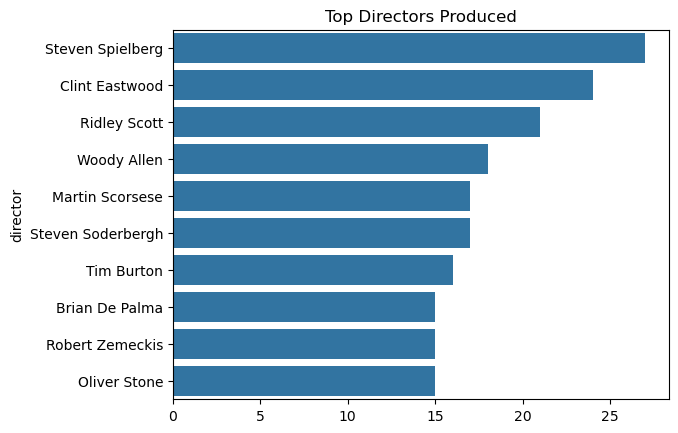

In [11]:
# Most frequent directors in the dataset
sns.barplot(x=director_mode.values, y=director_mode.index)
plt.title("Top Directors Produced")

In [12]:
# exact counts and what share of the dataset the top director represents
print(director_mode.head(10))
top_director_share = director_mode.iloc[0] / len(df_clean)
print(f"\nSteven Spielberg directed {director_mode.iloc[0]} of {len(df_clean)} movies "
      f"in this cleaned dataset ({top_director_share:.1%}).")

director
Steven Spielberg     27
Clint Eastwood       24
Ridley Scott         21
Woody Allen          18
Martin Scorsese      17
Steven Soderbergh    17
Tim Burton           16
Brian De Palma       15
Robert Zemeckis      15
Oliver Stone         15
Name: count, dtype: int64

Steven Spielberg directed 27 of 3853 movies in this cleaned dataset (0.7%).


The graph shows the directors with the **most movies produced** is Steven Spielberg

### Research Question 2: **Is there an association between higher budget and a higher revenue?**

Text(0.5, 1.0, 'Relationship Between Budget And Revenue')

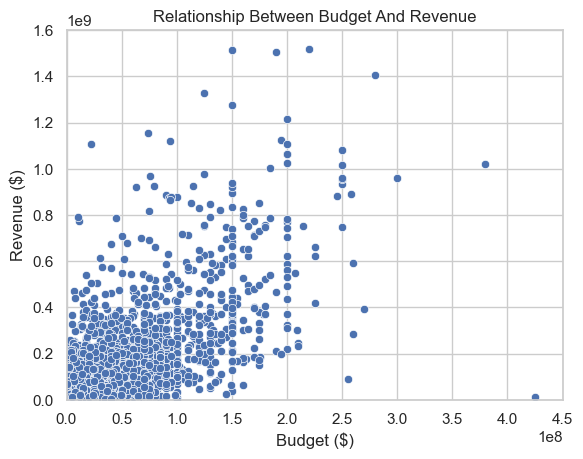

In [13]:
# Set a clean visual theme (optional)
sns.set_theme(style="whitegrid")

# Create the scatter plot using Seaborn
sns.scatterplot(data=df_clean, x="budget", y="revenue")

# Adding the exact limits from your code
plt.xlim(0, 450000000)
plt.ylim(0, 1600000000)

# Labeling your axes and title
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.title("Relationship Between Budget And Revenue")

The plot shows increasing budgets along with increasing revenue.

In [14]:
from scipy import stats

# Quantify the strength of the budget-revenue relationship
r, p_value = stats.pearsonr(df_clean['budget'], df_clean['revenue'])
print(f"Pearson correlation coefficient (r): {r:.3f}")
print(f"p-value: {p_value:.2e}")
print(f"R-squared (variance in revenue explained by budget): {r**2:.1%}")

# A more intuitive, probability-based way to say the same thing:
# "If a movie has an above-median budget, how likely is it to also have above-median revenue?"
median_budget = df_clean['budget'].median()
median_revenue = df_clean['revenue'].median()

high_budget_mask = df_clean['budget'] > median_budget

p_high_revenue_given_high_budget = (df_clean.loc[high_budget_mask, 'revenue'] > median_revenue).mean()
p_high_revenue_given_low_budget  = (df_clean.loc[~high_budget_mask, 'revenue'] > median_revenue).mean()

print(f"\nP(above-median revenue | above-median budget) = {p_high_revenue_given_high_budget:.1%}")
print(f"P(above-median revenue | below-median budget) = {p_high_revenue_given_low_budget:.1%}")

Pearson correlation coefficient (r): 0.689
p-value: 0.00e+00
R-squared (variance in revenue explained by budget): 47.4%

P(above-median revenue | above-median budget) = 74.5%
P(above-median revenue | below-median budget) = 26.0%


The correlation coefficient between budget and revenue is r ≈ 0.69 (R² ≈ 47%), a moderately strong positive relationship. Put another way, a movie with an above-median budget has roughly a 74% chance of also earning above-median revenue, versus only about 26% for a below-median-budget movie. This is an association, not proof that spending more causes higher revenue — Check Limitations Section

### Research Question 3: **Which genres were produced the most?**

Text(0, 0.5, 'Genres')

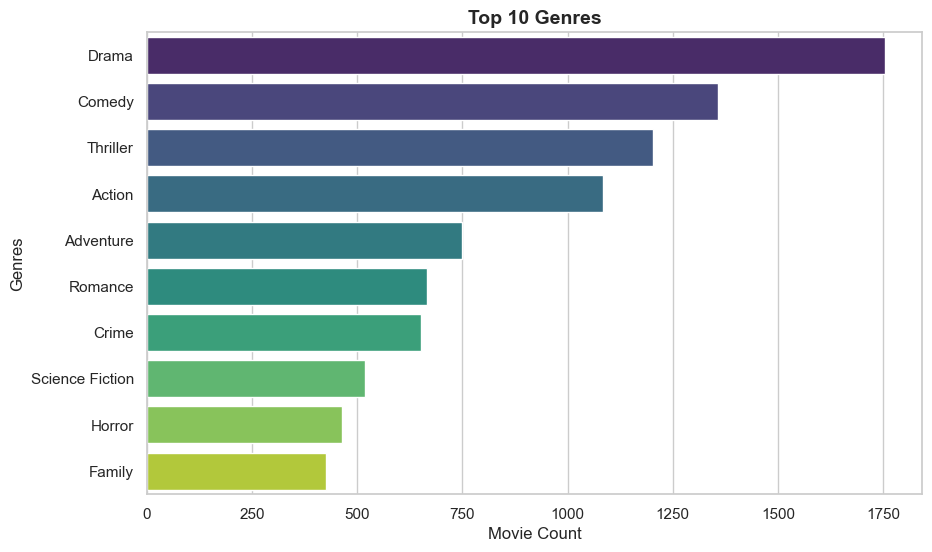

In [15]:
# Data manipulation remains the same
genres_df = df_clean.assign(genres=df_clean['genres'].str.split('|')).explode('genres')
most_genres = genres_df['genres'].value_counts()[0:10]

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create the plot using Seaborn (mapping index to y and values to x for horizontal bars)
plt.figure(figsize=(10, 6))
sns.barplot(x=most_genres.values, y=most_genres.index, hue=most_genres.index, palette="viridis", legend=False)

# Customizing plot details
plt.title('Top 10 Genres', fontsize=14, fontweight='bold')
plt.xlabel('Movie Count', fontsize=12)
plt.ylabel('Genres', fontsize=12)

We can see that **Drama** and **Comedy** are the most produced Genre

In [16]:
# what % of movies belong to each top genre (movies can have multiple genres)
genre_share = most_genres / len(df_clean) * 100
print(genre_share.round(1))
print(f"\n{genre_share.iloc[0]:.1f}% of movies in the cleaned dataset include the Drama genre.")

genres
Drama              45.5
Comedy             35.2
Thriller           31.2
Action             28.2
Adventure          19.4
Romance            17.3
Crime              16.9
Science Fiction    13.5
Horror             12.0
Family             11.0
Name: count, dtype: float64

45.5% of movies in the cleaned dataset include the Drama genre.


### Research Question 4: **Movies that has largest and lowest budgets**

In [17]:
import pprint
#defining the function
def calculate(column):
    #for highest earned profit
    high= df_clean[column].idxmax()
    high_details=pd.DataFrame(df_clean.loc[high])
    
    #for lowest earned profit
    low= df_clean[column].idxmin()
    low_details=pd.DataFrame(df_clean.loc[low])
    
    #collectin data in one place
    info=pd.concat([high_details, low_details], axis=1)
    
    return info

In [18]:
calculate('budget')

,682,810
popularity,0.25054,0.090186
budget,425000000.0,1.0
revenue,11087569.0,100.0
original_title,The Warrior's Way,Lost & Found
director,Sngmoo Lee,Jeff Pollack
runtime,100,95
genres,Adventure|Fantasy|Action|Western|Thriller,Comedy|Romance
release_date,2010-12-02 00:00:00,1999-04-23 00:00:00
vote_count,74,14
vote_average,6.4,4.8


Column with **id 682** shows the largest budget = 425000000 dollars Movie Title **"The Warrior's Way"** <br>
Column with **id 810** shows the smallest budget = 1 Dollar Movie Title **"Lost & Found"**

### Research Question 5: **Movies that has longest and shortest runtime**

In [19]:
#Calling the same function
calculate('runtime')

,653,1757
popularity,0.534192,0.208637
budget,18000000.0,10.0
revenue,871279.0,5.0
original_title,Carlos,Kid's Story
director,Olivier Assayas,Shinichiro Watanabe
runtime,338,15
genres,Crime|Drama|Thriller|History,Science Fiction|Animation
release_date,2010-05-19 00:00:00,2003-06-02 00:00:00
vote_count,35,16
vote_average,6.2,6.8


Column with id 653 shows the longest runtime = 338 minutes.**Movie Title "Carlos"** <br>
Column with id 1757 shows the shortest runtime = 15 minutes.**Movie Title "Kid's Story"**

### Research Question 6: **Movies with most and least earned revenue**

In [20]:
#Calculate revenue using the same function
calculate('revenue')

,344,1731
popularity,9.432768,0.462609
budget,237000000.0,6000000.0
revenue,2781505847.0,2.0
original_title,Avatar,Shattered Glass
director,James Cameron,Billy Ray
runtime,162,94
genres,Action|Adventure|Fantasy|Science Fiction,Drama|History
release_date,2009-12-10 00:00:00,2003-11-14 00:00:00
vote_count,8458,46
vote_average,7.1,6.4


Column with id 344 shows the most profitable (highest revenue) Movie Title **Avatar** <br>
Column with id 1731 shows the lowest revenue (Low revenue) Movie Title **Shattered Glass**

In [21]:
# What's the probability a movie in this dataset is profitable at all?
profit_probability = (df_clean['profit_adj'] > 0).mean()
print(f"P(movie is profitable) = {profit_probability:.1%}")
print(f"({(df_clean['profit_adj'] > 0).sum()} of {len(df_clean)} movies had positive inflation-adjusted profit)")

P(movie is profitable) = 72.1%
(2777 of 3853 movies had positive inflation-adjusted profit)


<a id='conclusions'></a>
## Conclusions

After conducting this analysis, a few patterns emerge:

1. **Budget and revenue are positively correlated** (r ≈ 0.69, R² ≈ 47%). Movies with above-median budgets had roughly a 74% chance of also earning above-median revenue, compared to ~26% for lower-budget movies — but budget alone does not guarantee success, and this is a correlation, not evidence that higher spending *causes* higher revenue.
2. **A small number of directors appear disproportionately often** in the dataset (e.g., Steven Spielberg directed ~0.7% of the cleaned movies), but this reflects volume of movies made, not necessarily a causal link between a specific director and box-office success.
3. **Drama and Comedy are the most common genres**, making up about 45.5% and 35.2% of movies respectively (movies can belong to multiple genres).
4. Overall, about 72% of movies in the cleaned dataset were profitable (revenue exceeded budget, inflation-adjusted).



<a id='Limitations'></a>
## Limitations

- **Missing data reduced the sample substantially.** Around 65% of the original 10,866 movies had missing or zero-value budget/revenue data and were dropped, leaving 3,853 movies. If movies with unreported financials differ systematically from those with complete data (e.g., are smaller, older, or less mainstream), the findings above may not generalize to the full population of movies.
- **Correlation is not causation.** The relationships identified between budget, director, genre, and revenue are associations only. Other unmeasured factors — marketing spend, franchise recognition, release timing, star power — likely influence both budget and revenue simultaneously and were not captured in this dataset.
- **Extreme values can dominate simple max/min lookups.** Questions 4–6 identify single record-holding movies (e.g., Avatar for highest revenue), which are useful illustrations but are outliers, not representative of a "typical" movie, and shouldn't be generalized into broad advice.
- **No formal statistical testing beyond correlation was performed** (e.g., no regression model controlling for multiple variables at once), so the relative importance of budget vs. genre vs. director could not be disentangled here.